# 3. Oil Spill Simulation with OpenDrift

This notebook will:
1. Set up an OpenDrift oil spill simulation
2. Use the ERA5 wind data and CMEMS ocean currents
3. Run the simulation and generate visualizations
4. Save the results for further analysis

First, we'll install OpenDrift and its dependencies.

In [1]:
from datetime import timedelta



In [2]:
# Install OpenDrift and required packages
import sys
import subprocess

def install_package(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

required_packages = ['opendrift', 'numpy<2.0.0', 'matplotlib', 'netcdf4', 'cmocean']
for package in required_packages:
    try:
        __import__(package.split('<')[0])  # Handle version constraints in package name
        print(f"{package} is already installed")
    except ImportError:
        print(f"Installing {package}...")
        install_package(package)

opendrift is already installed
numpy<2.0.0 is already installed
matplotlib is already installed
Installing netcdf4...
cmocean is already installed


In [3]:
# Robust paths, metadata, and date discovery
import os
import re
from datetime import datetime

# Ensure directories
processed_dir = os.path.join('..', 'data', 'processed')
outputs_dir = os.path.join('..', 'outputs')
animations_dir = os.path.join(outputs_dir, 'animations')
figures_dir = os.path.join(outputs_dir, 'figures')
for d in (outputs_dir, animations_dir, figures_dir):
    os.makedirs(d, exist_ok=True)

# Load metadata bounds safely
lat_min = lat_max = lon_min = lon_max = None
metadata_files = [f for f in os.listdir(processed_dir) if f.endswith('.metadata.json')]
if metadata_files:
    try:
        metadata_path = os.path.join(processed_dir, metadata_files[0])
        with open(metadata_path, 'r') as f:
            metadata = json.load(f)
        b = metadata.get('bounds', {})
        lat_min, lat_max = float(b.get('bottom')), float(b.get('top'))
        lon_min, lon_max = float(b.get('left')), float(b.get('right'))
        print("Loaded metadata:", metadata_path)
    except Exception as e:
        print("WARNING: Failed to read metadata bounds:", e)

# Discover date from available products
def dates_from_filenames(pattern):
    rx = re.compile(pattern)
    found = []
    for f in os.listdir(processed_dir):
        m = rx.match(f)
        if m:
            found.append(m.group(1))
    return set(found)

era5_dates = dates_from_filenames(r"era5_wind_(\d{8})\.nc$")
cmems_dates = dates_from_filenames(r"cmems_current_(\d{8})\.nc$")
common_dates = sorted(era5_dates & cmems_dates)
if not common_dates:
    raise FileNotFoundError("No common dates between ERA5 and CMEMS files in processed directory.")

# Pick first available date if not set earlier
if 'date' not in globals() or not isinstance(date, datetime):
    date = datetime.strptime(common_dates[0], '%Y%m%d')

# Build file paths and verify
era5_file = os.path.join(processed_dir, f'era5_wind_{date.strftime("%Y%m%d")}.nc')
cmems_file = os.path.join(processed_dir, f'cmems_current_{date.strftime("%Y%m%d")}.nc')
for p in (era5_file, cmems_file):
    if not os.path.isfile(p):
        raise FileNotFoundError(f"Missing required file: {p}")

print(f"Using date: {date:%Y-%m-%d}")
if all(v is not None for v in (lat_min, lat_max, lon_min, lon_max)):
    print(f"Bounds: {lat_min:.2f}..{lat_max:.2f} N, {lon_min:.2f}..{lon_max:.2f} E")
else:
    print("Bounds: not available (metadata missing)")


Using date: 2023-04-23
Bounds: not available (metadata missing)


In [4]:
# Import required libraries
import os
import json
from datetime import datetime, timedelta
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
from opendrift.readers import reader_netCDF_CF_generic
from opendrift.models.openoil import OpenOil
import cmocean  # For ocean colormaps

# Set paths
processed_dir = os.path.join('..', 'data', 'processed')
outputs_dir = os.path.join('..', 'outputs')
animations_dir = os.path.join(outputs_dir, 'animations')
figures_dir = os.path.join(outputs_dir, 'figures')

# Create output directories if they don't exist
os.makedirs(animations_dir, exist_ok=True)
os.makedirs(figures_dir, exist_ok=True)

# Load metadata
metadata_files = [f for f in os.listdir(processed_dir) if f.endswith('.metadata.json')]
if metadata_files:
    metadata_path = os.path.join(processed_dir, metadata_files[0])
    with open(metadata_path, 'r') as f:
        metadata = json.load(f)
    print("Loaded metadata from:", metadata_path)
    
    # Extract coordinates and date
    bounds = metadata['bounds']
    lat_min, lat_max = bounds['bottom'], bounds['top']
    lon_min, lon_max = bounds['left'], bounds['right']
    
    # Extract date from filename
    filename = metadata_files[0].split('.metadata.json')[0]
    date_str = filename.split('-00_00')[0]
    date = datetime.strptime(date_str, '%Y-%m-%d')
    
    print(f"\nSimulation information:")
    print(f"Date: {date.strftime('%Y-%m-%d')}")
    print(f"Area: {lat_min:.2f}°N to {lat_max:.2f}°N, {lon_min:.2f}°E to {lon_max:.2f}°E")


Loaded metadata from: ..\data\processed\2023-04-23-00_00_2023-04-23-23_59_Sentinel-1_IW_VV+VH_VV_-_decibel_gamma0.tiff.metadata.json

Simulation information:
Date: 2023-04-23
Area: 13.20°N to 13.40°N, 121.40°E to 121.70°E


In [5]:
# Load ERA5 and CMEMS data
print("Loading environmental data...")

# Create a constant reader for waves
from opendrift.readers import reader_constant

wave_reader = reader_constant.Reader({
    'sea_surface_wave_significant_height': 0.0,
    'sea_surface_wave_stokes_drift_x_velocity': 0.0,
    'sea_surface_wave_stokes_drift_y_velocity': 0.0,
})
print("\nWave reader variables:", wave_reader.variables)

# Load ERA5 wind data; map u10/v10 directly to x_wind/y_wind
era5_file = os.path.join(processed_dir, f'era5_wind_{date.strftime("%Y%m%d")}.nc')
era5_reader = reader_netCDF_CF_generic.Reader(
    filename=era5_file,
    standard_name_mapping={
        'u10': 'x_wind',
        'v10': 'y_wind'
    }
)
print("\nERA5 reader variables:", era5_reader.variables)

# Load CMEMS ocean current data with standard names
cmems_file = os.path.join(processed_dir, f'cmems_current_{date.strftime("%Y%m%d")}.nc')
cmems_reader = reader_netCDF_CF_generic.Reader(
    filename=cmems_file,
    standard_name_mapping={
        'uo': 'eastward_sea_water_velocity',
        'vo': 'northward_sea_water_velocity'
    }
)
print("\nCMEMS reader variables:", cmems_reader.variables)

# Print time coverage
print("\nTime coverage:")
print(f"ERA5: {era5_reader.start_time} to {era5_reader.end_time}")
print(f"CMEMS: {cmems_reader.start_time} to {cmems_reader.end_time}")

Loading environmental data...

Wave reader variables: ['sea_surface_wave_significant_height', 'sea_surface_wave_stokes_drift_x_velocity', 'sea_surface_wave_stokes_drift_y_velocity', 'sea_surface_wave_stokes_drift_speed']

ERA5 reader variables: ['x_wind', 'y_wind', 'wind_speed']

CMEMS reader variables: ['eastward_sea_water_velocity', 'northward_sea_water_velocity', 'x_sea_water_velocity', 'y_sea_water_velocity', 'sea_water_speed']

Time coverage:
ERA5: 2023-04-23 00:00:00 to 2023-04-23 23:00:00
CMEMS: 2023-04-23 00:00:00 to 2023-04-24 00:00:00


In [6]:
# Examine file structure
print("ERA5 wind data variables:")
era5_ds = xr.open_dataset(era5_file)
print(era5_ds.variables)

print("\nCMEMS current data variables:")
cmems_ds = xr.open_dataset(cmems_file)
print(cmems_ds.variables)

ERA5 wind data variables:
Frozen({'u10': <xarray.Variable (valid_time: 24, latitude: 3, longitude: 4)> Size: 1kB
[288 values with dtype=float32]
Attributes: (12/32)
    GRIB_paramId:                             165
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      12
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               m s**-1
    long_name:                                10 metre U wind component
    units:                                    m s**-1
    standard_name:                            unknown
    GRIB_surface:                             0.0, 'v10': <xarray.Variable (valid_time: 24, latitude: 3, longitude: 4)> Size: 1kB
[288 values with dtype=float32]
Attributes: (12/32)
    GRIB_paramId:

In [7]:
# Initialize the OpenOil model
print("Initializing OpenOil model...")
o = OpenOil(loglevel=20)  # 20=info, 10=debug

# Add readers (priority order: currents, wind, waves)
print("\nAdding readers...")
try:
    # Add each reader separately with error handling
    o.add_reader(cmems_reader)
    print("✓ CMEMS reader added")
    o.add_reader(era5_reader)
    print("✓ ERA5 reader added")
    o.add_reader(wave_reader)
    print("✓ Wave reader added")
    print("\nAll readers added successfully!")
except Exception as e:
    print(f"\nError adding readers: {str(e)}")
    import traceback
    traceback.print_exc()
    raise


Initializing OpenOil model...


21:30:51 INFO    opendrift:569: OpenDriftSimulation initialised (version 1.14.4)



Adding readers...
✓ CMEMS reader added
✓ ERA5 reader added
✓ Wave reader added

All readers added successfully!


In [8]:
import logging
from typing import Dict, Any, Optional, Tuple
import numpy as np

# Set up logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

def validate_config_value(name: str, value: float, min_val: Optional[float] = None, 
                        max_val: Optional[float] = None) -> None:
    """
    Validate a configuration value against optional minimum and maximum bounds.
    
    Args:
        name: Name of the configuration parameter
        value: Value to validate
        min_val: Optional minimum allowed value
        max_val: Optional maximum allowed value
        
    Raises:
        ValueError: If value is outside the allowed bounds
    """
    if min_val is not None and value < min_val:
        raise ValueError(f"{name} must be >= {min_val}")
    if max_val is not None and value > max_val:
        raise ValueError(f"{name} must be <= {max_val}")

def verify_reader_initialization(reader: Any, reader_name: str) -> None:
    """
    Verify that a reader is properly initialized with required attributes.
    
    Args:
        reader: The reader object to verify
        reader_name: Name of the reader for error messages
        
    Raises:
        AttributeError: If reader lacks required attributes
    """
    required_attrs = ['start_time', 'end_time']
    for attr in required_attrs:
        if not hasattr(reader, attr):
            raise AttributeError(f"{reader_name} not properly initialized: missing {attr}")

def validate_time_coverage(date: Any, era_reader: Any, cmems_reader: Any) -> None:
    """
    Validate that the simulation date is within the time coverage of both readers.
    
    Args:
        date: Simulation date to validate
        era_reader: ERA5 reader object
        cmems_reader: CMEMS reader object
        
    Raises:
        ValueError: If date is outside reader coverage
    """
    try:
        # Verify reader initialization
        verify_reader_initialization(era_reader, "ERA5 reader")
        verify_reader_initialization(cmems_reader, "CMEMS reader")
        
        # Check time coverage
        if not (era_reader.start_time <= date <= era_reader.end_time):
            raise ValueError(
                f"Seed date {date} outside ERA5 coverage "
                f"({era_reader.start_time} to {era_reader.end_time})"
            )
        if not (cmems_reader.start_time <= date <= cmems_reader.end_time):
            raise ValueError(
                f"Seed date {date} outside CMEMS coverage "
                f"({cmems_reader.start_time} to {cmems_reader.end_time})"
            )
    except (AttributeError, ValueError) as e:
        logger.error(f"Time coverage validation failed: {str(e)}")
        raise

def verify_process_enabled(o: Any, process_name: str) -> None:
    """
    Verify that a specific process is enabled in the model.
    
    Args:
        o: OpenDrift object
        process_name: Name of the process to verify
        
    Raises:
        RuntimeError: If process is not enabled
    """
    if not o.get_config(f'processes:{process_name}'):
        raise RuntimeError(f"Failed to enable {process_name} process")

# Configuration parameters with documentation
CONFIG_PARAMS = {
    'horizontal_diffusivity': {
        'value': 1.0,
        'min': 0.0,
        'max': 10.0,
        'unit': 'm²/s',
        'description': 'Surface-scale horizontal diffusion coefficient'
    },
    'wind_uncertainty': {
        'value': 0.2,
        'min': 0.0,
        'max': 1.0,
        'unit': 'fraction',
        'description': 'Fractional uncertainty in wind velocity components (20% of wind speed)'
    },
    'current_uncertainty': {
        'value': 0.1,
        'min': 0.0,
        'max': 1.0,
        'unit': 'fraction',
        'description': 'Fractional uncertainty in ocean current components (10% of current speed)'
    }
}

# Available oil types with descriptions
OIL_TYPES = {
    'GENERIC MEDIUM CRUDE': {
        'description': 'Medium-weight crude oil with typical properties',
        'use_case': 'General-purpose simulations where specific oil type is unknown'
    }
}

logger.info("Setting oil properties and model configuration...")

try:
    # Validate and set oil type
    oil_type = 'GENERIC MEDIUM CRUDE'
    if oil_type not in OIL_TYPES:
        raise ValueError(f"Invalid oil type: {oil_type}. Available types: {list(OIL_TYPES.keys())}")
    o.set_config('seed:oil_type', oil_type)
    logger.info(f"Using oil type: {oil_type} - {OIL_TYPES[oil_type]['description']}")

    # Set coastline action
    # Options: 'none' (particles continue), 'stranding' (particles stop), 'previous' (maintain last position)
    # Using 'previous' for most realistic behavior: particles remain active but don't penetrate coastline
    o.set_config('general:coastline_action', 'previous')
    logger.info("Coastline action set to 'previous': particles maintain last position when touching coast")

    # Set and validate diffusion and uncertainty parameters
    for param_name, config in CONFIG_PARAMS.items():
        value = config['value']
        validate_config_value(param_name, value, config['min'], config['max'])
        o.set_config(f'drift:{param_name}', value)
        logger.info(f"Set {param_name} = {value} {config['unit']} ({config['description']})")

    # Enable and verify core processes
    core_processes = ['evaporation', 'dispersion', 'emulsification']
    for process in core_processes:
        o.set_config(f'processes:{process}', True)
        verify_process_enabled(o, process)
        logger.info(f"Enabled {process} process")

    logger.info("Model configuration completed successfully")

except (ValueError, RuntimeError, AttributeError) as e:
    logger.error(f"Configuration failed: {str(e)}")
    raise

21:30:54 INFO    __main__:126: Setting oil properties and model configuration...
21:30:54 INFO    __main__:134: Using oil type: GENERIC MEDIUM CRUDE - Medium-weight crude oil with typical properties
21:30:54 INFO    __main__:140: Coastline action set to 'previous': particles maintain last position when touching coast
21:30:54 INFO    __main__:147: Set horizontal_diffusivity = 1.0 m²/s (Surface-scale horizontal diffusion coefficient)
21:30:54 INFO    __main__:147: Set wind_uncertainty = 0.2 fraction (Fractional uncertainty in wind velocity components (20% of wind speed))
21:30:54 INFO    __main__:147: Set current_uncertainty = 0.1 fraction (Fractional uncertainty in ocean current components (10% of current speed))
21:30:54 INFO    __main__:154: Enabled evaporation process
21:30:54 INFO    __main__:154: Enabled dispersion process
21:30:54 INFO    __main__:154: Enabled emulsification process
21:30:54 INFO    __main__:156: Model configuration completed successfully


In [9]:
# Set up release point
# Use center of the area as release point
release_lon = (lon_min + lon_max) / 2
release_lat = (lat_min + lat_max) / 2

# Reproducibility
np.random.seed(42)

# Release time should be within the data time coverage
# Use the date from metadata and set time to noon
from datetime import datetime, timedelta

release_time = datetime.combine(date.date(), datetime.min.time()) + timedelta(hours=12)
num_particles = 1000  # Number of particles to simulate

print(f"Release configuration:")
print(f"Location: {release_lat:.3f}°N, {release_lon:.3f}°E")
print(f"Time: {release_time}")
print(f"Number of particles: {num_particles}")

# Verify release time is within reader coverage
if release_time < era5_reader.start_time or release_time > era5_reader.end_time:
    print(f"WARNING: Release time {release_time} outside ERA5 coverage ({era5_reader.start_time} to {era5_reader.end_time})")
    # Adjust to start time if outside
    if release_time < era5_reader.start_time:
        release_time = era5_reader.start_time
        print(f"Adjusted release time to: {release_time}")
    elif release_time > era5_reader.end_time:
        release_time = era5_reader.end_time - timedelta(hours=1)
        print(f"Adjusted release time to: {release_time}")

# Seed oil elements
try:
    o.seed_elements(lon=release_lon, lat=release_lat,
                    radius=100,  # Release within 100m radius
                    number=num_particles,
                    time=release_time)
    print("\nSeeded elements scheduled successfully!")
except Exception as e:
    print(f"\nError seeding elements: {str(e)}")
    import traceback
    traceback.print_exc()
    raise


21:31:00 INFO    opendrift.models.openoil.openoil:1708: Oil type not specified, using default: GENERIC MEDIUM CRUDE
21:31:00 INFO    opendrift.models.openoil.adios.dirjs:86: Querying ADIOS database for oil: GENERIC MEDIUM CRUDE
21:31:00 INFO    opendrift.models.openoil.openoil:1717: Using density 877.5726099999999 and viscosity 4.543140171865051e-05 of oiltype GENERIC MEDIUM CRUDE
21:31:00 INFO    opendrift.models.basemodel.environment:203: Adding a global landmask from GSHHG


Release configuration:
Location: 13.300°N, 121.549°E
Time: 2023-04-23 12:00:00
Number of particles: 1000


21:31:06 INFO    opendrift.models.basemodel.environment:227: Fallback values will be used for the following variables which have no readers: 
21:31:06 INFO    opendrift.models.basemodel.environment:230: 	sea_surface_height: 0.000000
21:31:06 INFO    opendrift.models.basemodel.environment:230: 	upward_sea_water_velocity: 0.000000
21:31:06 INFO    opendrift.models.basemodel.environment:230: 	sea_surface_wave_period_at_variance_spectral_density_maximum: 0.000000
21:31:06 INFO    opendrift.models.basemodel.environment:230: 	sea_surface_wave_mean_period_from_variance_spectral_density_second_frequency_moment: 0.000000
21:31:06 INFO    opendrift.models.basemodel.environment:230: 	sea_ice_area_fraction: 0.000000
21:31:06 INFO    opendrift.models.basemodel.environment:230: 	sea_ice_x_velocity: 0.000000
21:31:06 INFO    opendrift.models.basemodel.environment:230: 	sea_ice_y_velocity: 0.000000
21:31:06 INFO    opendrift.models.basemodel.environment:230: 	sea_water_temperature: 10.000000
21:31:06 


Seeded elements scheduled successfully!


In [10]:
print("Running oil spill simulation...")

# Verify readers have time coverage
if not hasattr(era5_reader, 'end_time') or not hasattr(cmems_reader, 'end_time'):
    raise RuntimeError("Readers not properly initialized with time coverage")

# Collect available time ranges from readers
time_ends = []
for reader_name, reader in [
    ("ERA5", era5_reader),
    ("CMEMS", cmems_reader),
]:
    end_t = getattr(reader, "end_time", None)
    if end_t is not None:
        time_ends.append(end_t)
    else:
        print(f"⚠️ {reader_name} reader has no end_time")

# Choose the earliest available end_time among valid readers
if len(time_ends) == 0:
    raise RuntimeError("❌ No valid readers with end_time found! Check your input files.")
end_time = min(time_ends)

# Define duration within available data
duration_hours = 24
if release_time + timedelta(hours=duration_hours) > end_time:
    print(f"⚠️ Simulation duration reduced to match available data")
    duration_hours = int((end_time - release_time).total_seconds() / 3600)
    if duration_hours < 1:
        print(f"❌ Not enough data coverage for simulation!")
        raise ValueError(f"Release time {release_time} is too close to end of data {end_time}")

time_step_minutes = 30

# Unique output filename
unique_tag = datetime.now().strftime("%H%M%S")
outfile = os.path.join(
    outputs_dir,
    f'simulation_{release_time.strftime("%Y%m%dT%H%MZ")}_{unique_tag}.nc'
)

print(f"\nSimulation parameters:")
print(f"Release time: {release_time}")
print(f"Duration: {duration_hours} hours")
print(f"Time step: {time_step_minutes} minutes")
print(f"Output file: {outfile}")

# Run simulation safely within data coverage
try:
    o.run(
        duration=timedelta(hours=duration_hours),
        time_step=timedelta(minutes=time_step_minutes),
        time_step_output=timedelta(hours=1),
        outfile=outfile,
        export_variables=[
            'mass_oil', 'water_fraction', 'density',
            'area', 'evaporated_mass', 'viscosity', 'age_seconds'
        ]
    )
    print("\n✓ Simulation complete!")
except Exception as e:
    print(f"\n❌ Simulation failed: {str(e)}")
    import traceback
    traceback.print_exc()
    raise

print(f"Final number of active elements: {o.num_elements_active()}")
print(f"Number of deactivated elements: {o.num_elements_deactivated()}")
print(f"Output written to: {outfile}")


21:31:10 INFO    opendrift:1783: Skipping environment variable upward_sea_water_velocity because of condition ['drift:vertical_advection', 'is', False]
21:31:10 INFO    opendrift:1794: Storing previous values of element property lon because of condition (('general:coastline_action', 'in', ['stranding', 'previous']), 'or', ('general:seafloor_action', 'in', ['previous']))
21:31:10 INFO    opendrift:1794: Storing previous values of element property lat because of condition (('general:coastline_action', 'in', ['stranding', 'previous']), 'or', ('general:seafloor_action', 'in', ['previous']))


21:31:10 INFO    opendrift:945: Using existing reader for land_binary_mask to move elements to ocean
21:31:11 INFO    opendrift:975: All points are in ocean
21:31:11 INFO    opendrift.models.openoil.openoil:692: Oil-water surface tension is 0.031369 Nm
21:31:11 INFO    opendrift.models.openoil.openoil:705: Max water fraction not available for GENERIC MEDIUM CRUDE, using default
21:31:11 INFO    opendrift:2090: 2023-04-23 12:00:00 - step 1 of 22 - 1000 active elements (0 deactivated)


Running oil spill simulation...
⚠️ Simulation duration reduced to match available data

Simulation parameters:
Release time: 2023-04-23 12:00:00
Duration: 11 hours
Time step: 30 minutes
Output file: ..\outputs\simulation_20230423T1200Z_233110.nc


21:31:11 INFO    opendrift:2090: 2023-04-23 12:30:00 - step 2 of 22 - 1000 active elements (0 deactivated)
21:31:11 INFO    opendrift:2090: 2023-04-23 13:00:00 - step 3 of 22 - 1000 active elements (0 deactivated)
21:31:11 INFO    opendrift:2090: 2023-04-23 13:30:00 - step 4 of 22 - 1000 active elements (0 deactivated)
21:31:11 INFO    opendrift:2090: 2023-04-23 14:00:00 - step 5 of 22 - 1000 active elements (0 deactivated)
21:31:11 INFO    opendrift:2090: 2023-04-23 14:30:00 - step 6 of 22 - 1000 active elements (0 deactivated)
21:31:12 INFO    opendrift:2090: 2023-04-23 15:00:00 - step 7 of 22 - 1000 active elements (0 deactivated)
21:31:12 INFO    opendrift:2090: 2023-04-23 15:30:00 - step 8 of 22 - 1000 active elements (0 deactivated)
21:31:12 INFO    opendrift:2090: 2023-04-23 16:00:00 - step 9 of 22 - 1000 active elements (0 deactivated)
21:31:12 INFO    opendrift:2090: 2023-04-23 16:30:00 - step 10 of 22 - 1000 active elements (0 deactivated)
21:31:12 INFO    opendrift:2090: 202


✓ Simulation complete!
Final number of active elements: 1000
Number of deactivated elements: 0
Output written to: ..\outputs\simulation_20230423T1200Z_233110.nc


Creating visualizations...


<Figure size 1000x800 with 0 Axes>

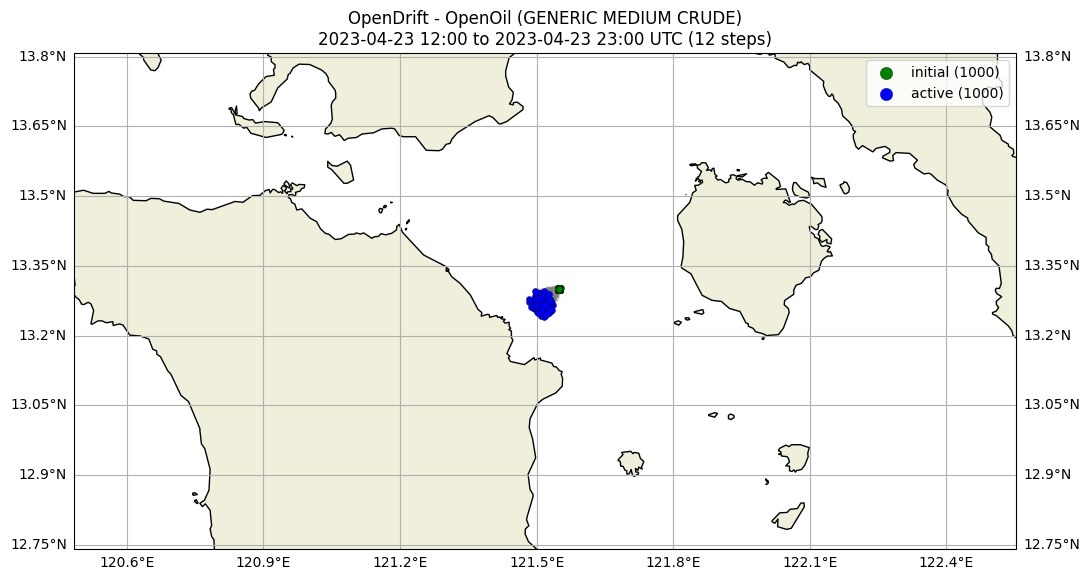

✓ Successfully created trajectory plot
✓ Successfully plotted mass_oil
✓ Successfully plotted water_fraction
✓ Successfully plotted density
✓ Successfully plotted viscosity
✓ Successfully created properties plot
✓ Successfully created properties plot


<Figure size 1000x800 with 0 Axes>

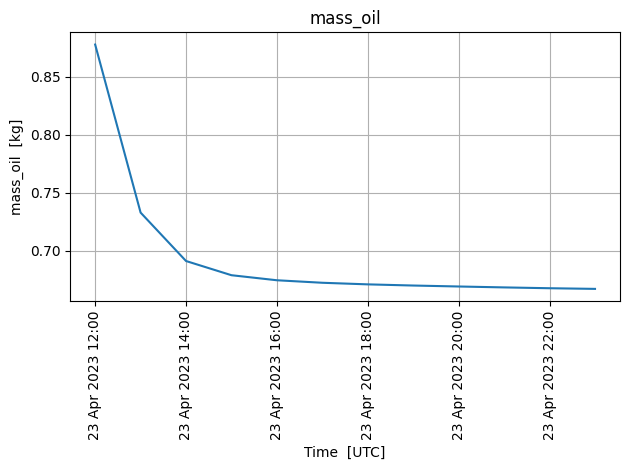

⚠ Warning: Could not create density plot: No mappable was found to use for colorbar creation. First define a mappable such as an image (with imshow) or a contour set (with contourf).

Visualization files summary:
✓ Trajectory: trajectory_20230423T1200Z.png
✓ Properties: properties_20230423T1200Z.png
✗ Density: Not created

Available plotting methods in OpenDrift:
- plot_comparison_colors
- plot_droplet_spectrum
- plot_environment
- plot_memory_usage
- plot_oil_budget
- plot_oil_watercontent_and_viscosity
- plot_property
- plot_vertical_distribution


Traceback (most recent call last):
  File "C:\Users\Compu City\AppData\Local\Temp\ipykernel_20924\680779543.py", line 72, in <module>
    plt.colorbar(label='Oil mass [kg]')
  File "C:\Users\Compu City\AppData\Roaming\Python\Python312\site-packages\matplotlib\pyplot.py", line 2529, in colorbar
    raise RuntimeError('No mappable was found to use for colorbar '
RuntimeError: No mappable was found to use for colorbar creation. First define a mappable such as an image (with imshow) or a contour set (with contourf).


In [13]:
# Create visualizations
print("Creating visualizations...")

stamp = release_time.strftime("%Y%m%dT%H%MZ")
traj_file = None
props_file = None
dens_file = None

# Create a figure for trajectory
plt.figure(figsize=(10, 8))
try:
    # Plot the trajectories with mass_oil as color
    o.animation_mode = False  # Ensure we're not in animation mode
    o.plot(buffer=0.5, 
           show_trajectories=True,
           fast=False)  # Disable fast mode for better quality
    plt.title('Oil Spill Trajectory')
    plt.grid(True)
    traj_file = os.path.join(figures_dir, f'trajectory_{stamp}.png')
    plt.savefig(traj_file, bbox_inches='tight', dpi=300)
    plt.close()
    print(f"✓ Successfully created trajectory plot")
except Exception as e:
    print(f"⚠ Warning: Could not create trajectory plot: {str(e)}")
    import traceback
    traceback.print_exc()

# Plot oil parameters over time
plt.figure(figsize=(10, 6))
time_array_hours = np.array([])
try:
    if hasattr(o, 'result') and 'time' in o.result:
        time_array_hours = ((o.result.time - o.result.time[0]) / np.timedelta64(1, 'h')).astype(float)
        
        for var in ['mass_oil', 'water_fraction', 'density', 'viscosity']:
            if var in o.result:
                try:
                    dims = list(o.result[var].dims)
                    reduce_dim = 'trajectory' if 'trajectory' in dims else (dims[1] if len(dims) > 1 else None)
                    values = o.result[var].mean(dim=reduce_dim).values if reduce_dim else o.result[var].values
                    plt.plot(time_array_hours, values, label=var.replace('_', ' ').title())
                    print(f"✓ Successfully plotted {var}")
                except Exception as e:
                    print(f"⚠ Warning: Could not plot {var}: {str(e)}")
            else:
                print(f"⚠ Warning: Variable {var} not found in results")

        plt.grid(True)
        plt.xlabel('Hours since release')
        plt.ylabel('Value')
        plt.legend()
        plt.title('Oil Parameters Over Time')
        plt.tight_layout()
        props_file = os.path.join(figures_dir, f'properties_{stamp}.png')
        plt.savefig(props_file, bbox_inches='tight', dpi=300)
        print(f"✓ Successfully created properties plot")
    else:
        print("⚠ Warning: No time data found in results")
except Exception as e:
    print(f"⚠ Warning: Could not create properties plot: {str(e)}")
    import traceback
    traceback.print_exc()
finally:
    plt.close()

# Plot oil mass distribution
plt.figure(figsize=(10, 8))
try:
    # Plot the mass_oil property directly
    o.plot_property('mass_oil', mean=True)
    plt.title('Oil Mass Distribution')
    plt.colorbar(label='Oil mass [kg]')
    dens_file = os.path.join(figures_dir, f'density_{stamp}.png')
    plt.savefig(dens_file, bbox_inches='tight', dpi=300)
    print(f"✓ Successfully created density plot")
except Exception as e:
    print(f"⚠ Warning: Could not create density plot: {str(e)}")
    import traceback
    traceback.print_exc()
finally:
    plt.close()

print("\nVisualization files summary:")
for label, filepath in [("Trajectory", traj_file), ("Properties", props_file), ("Density", dens_file)]:
    if filepath:
        print(f"✓ {label}: {os.path.basename(filepath)}")
    else:
        print(f"✗ {label}: Not created")

# Print available plotting methods
print("\nAvailable plotting methods in OpenDrift:")
plot_methods = [method for method in dir(o) if method.startswith('plot_')]
print("\n".join(f"- {method}" for method in plot_methods))

In [14]:
# Create animation of oil spill movement manually using matplotlib
print("Creating animation...")

try:
    # Check if simulation results exist
    if not hasattr(o, 'result') or o.result is None:
        print("Warning: No simulation results in memory. Trying to load from file...")
        
        # Try to find the most recent simulation file
        import glob
        sim_files = glob.glob(os.path.join(outputs_dir, 'simulation_*.nc'))
        if sim_files:
            # Get the most recent file
            latest_file = max(sim_files, key=os.path.getmtime)
            print(f"Loading results from: {latest_file}")
            try:
                # Import results into OpenDrift object
                o.io_import_file(latest_file)
                print("Results loaded successfully!")
            except Exception as load_error:
                print(f"Error loading file: {load_error}")
                raise ValueError("Could not load simulation results from file")
        else:
            raise ValueError("No simulation results found. Please run the simulation first.")
    
    # Verify results are loaded
    if not hasattr(o, 'result') or o.result is None:
        raise ValueError("No simulation results available for animation")
    
    print(f"Number of trajectories: {len(o.result.trajectory)}")
    print(f"Number of time steps: {len(o.result.time)}")
    
    # Extract data from results
    lon_data = o.result.lon.values  # Shape: (trajectory, time)
    lat_data = o.result.lat.values   # Shape: (trajectory, time)
    mass_oil_data = o.result.mass_oil.values  # Shape: (trajectory, time)
    time_data = o.result.time.values
    
    # Calculate bounds with buffer
    lon_min, lon_max = lon_data.min() - 0.05, lon_data.max() + 0.05
    lat_min, lat_max = lat_data.min() - 0.05, lat_data.max() + 0.05
    
    print("Creating manual animation using matplotlib...")
    
    # Set up the figure
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Initialize scatter plot (will be updated each frame)
    scatter = ax.scatter([], [], c=[], s=50, cmap='viridis', 
                        vmin=mass_oil_data.min(), vmax=mass_oil_data.max(),
                        alpha=0.6, edgecolors='k', linewidths=0.5)
    
    # Set up axes
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    ax.set_xlabel('Longitude (°E)', fontsize=12)
    ax.set_ylabel('Latitude (°N)', fontsize=12)
    ax.set_title('Oil Spill Movement Over Time', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax, label='Oil Mass (kg)')
    
    # Add time text
    time_text = ax.text(0.02, 0.98, '', transform=ax.transAxes, 
                       fontsize=12, verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    # Animation update function
    def update(frame):
        """Update the plot for each frame."""
        # Get current time step data
        current_lon = lon_data[:, frame]
        current_lat = lat_data[:, frame]
        current_mass = mass_oil_data[:, frame]
        
        # Filter out invalid data (NaN or status != 0)
        if 'status' in o.result:
            status = o.result.status.values[:, frame]
            valid = (status == 0) & (~np.isnan(current_lon)) & (~np.isnan(current_lat))
        else:
            valid = (~np.isnan(current_lon)) & (~np.isnan(current_lat))
        
        if np.any(valid):
            scatter.set_offsets(np.c_[current_lon[valid], current_lat[valid]])
            scatter.set_array(current_mass[valid])
            
            # Update time text
            time_str = pd.Timestamp(time_data[frame]).strftime('%Y-%m-%d %H:%M:%S UTC')
            time_text.set_text(f'Time: {time_str}\nParticles: {np.sum(valid)}')
        
        return scatter, time_text
    
    # Create animation
    from matplotlib.animation import FuncAnimation
    import pandas as pd
    
    print("Generating animation frames...")
    anim = FuncAnimation(fig, update, frames=len(time_data), 
                         interval=500, blit=False, repeat=True)
    
    # Save the animation
    anim_file = os.path.join(animations_dir, f'oil_movement_{stamp}.mp4')
    print(f"Saving animation to: {anim_file}")
    
    # Try saving with different formats
    try:
        anim.save(anim_file, fps=2, dpi=100, writer='ffmpeg', bitrate=1800)
        print("Successfully saved as MP4")
    except Exception as save_error:
        print(f"Warning: Could not save as MP4 ({save_error}). Trying GIF format...")
        try:
            anim_file = os.path.join(animations_dir, f'oil_movement_{stamp}.gif')
            anim.save(anim_file, fps=2, writer='pillow')
            print("Successfully saved as GIF")
        except Exception as gif_error:
            print(f"Warning: Could not save as GIF either ({gif_error}). Trying HTML5 format...")
            try:
                anim_file = os.path.join(animations_dir, f'oil_movement_{stamp}.html')
                anim.save(anim_file, fps=2, writer='html')
                print("Successfully saved as HTML")
            except Exception as html_error:
                print(f"All save formats failed. Last error: {html_error}")
                print("Animation created but could not be saved. You can display it with plt.show()")
                # Keep the figure open for display
                plt.show(block=False)
                raise
    
    plt.close(fig)
    
    print("Animation successfully created and saved!")
    print(f"Animation saved to: {anim_file}")

except Exception as e:
    print(f"Error creating animation: {str(e)}")
    import traceback
    traceback.print_exc()
    # Make sure to close any open figures
    plt.close('all')

21:32:43 WARNING matplotlib.animation:1073: MovieWriter ffmpeg unavailable; using Pillow instead.
21:32:43 WARNING matplotlib.animation:1073: MovieWriter ffmpeg unavailable; using Pillow instead.


Creating animation...
Number of trajectories: 1000
Number of time steps: 12
Creating manual animation using matplotlib...
Generating animation frames...
Saving animation to: ..\outputs\animations\oil_movement_20230423T1200Z.mp4
Successfully saved as GIF
Animation successfully created and saved!
Animation saved to: ..\outputs\animations\oil_movement_20230423T1200Z.gif
Successfully saved as GIF
Animation successfully created and saved!
Animation saved to: ..\outputs\animations\oil_movement_20230423T1200Z.gif


In [15]:
# Load and examine the simulation results
from netCDF4 import Dataset
import glob

# Find the most recent simulation file
sim_files = glob.glob(os.path.join(outputs_dir, 'simulation_*.nc'))
if not sim_files:
    print("No simulation files found. Please run the simulation first.")
else:
    sim_path = max(sim_files, key=os.path.getmtime)  # Get the most recent file
    print(f"Loading simulation from: {sim_path}")
    ds = Dataset(sim_path)
    print("\nDataset structure:")
    print(ds)
    ds.close()


Loading simulation from: ..\outputs\simulation_20230423T1200Z_233110.nc

Dataset structure:
<class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    Conventions: CF-1.11, ACDD-1.3
    standard_name_vocabulary: CF Standard Name Table v85
    featureType: trajectory
    title: OpenDrift trajectory simulation
    summary: Output from simulation with OpenDrift framework
    keywords: trajectory, drift, lagrangian, simulation
    history: Created 2025-11-28 23:31:10.984140
    date_created: 2025-11-28T23:31:10.984140
    source: Output from simulation with OpenDrift
    model_url: https://github.com/OpenDrift/opendrift
    opendrift_class: OpenOil
    opendrift_module: opendrift.models.openoil.openoil
    readers: odict_keys(['..\\data\\processed\\cmems_current_20230423.nc', '..\\data\\processed\\era5_wind_20230423.nc', 'constant_reader', 'global_landmask'])
    time_coverage_start: 2023-04-23 12:00:00
    time_step_calculation: 0:30:00
    time_step_output: 1:00:00


Dataset structure:
<xarray.Dataset> Size: 436kB
Dimensions:         (trajectory: 1000, time: 12)
Coordinates:
  * trajectory      (trajectory) int32 4kB 0 1 2 3 4 5 ... 995 996 997 998 999
  * time            (time) datetime64[ns] 96B 2023-04-23T12:00:00 ... 2023-04...
Data variables:
    status          (trajectory, time) float64 96kB ...
    age_seconds     (trajectory, time) float32 48kB ...
    lon             (trajectory, time) float32 48kB ...
    lat             (trajectory, time) float32 48kB ...
    mass_oil        (trajectory, time) float32 48kB ...
    viscosity       (trajectory, time) float32 48kB ...
    density         (trajectory, time) float32 48kB ...
    water_fraction  (trajectory, time) float32 48kB ...
Attributes: (12/162)
    Conventions:                                                             ...
    standard_name_vocabulary:                                                ...
    featureType:                                                             ...
  

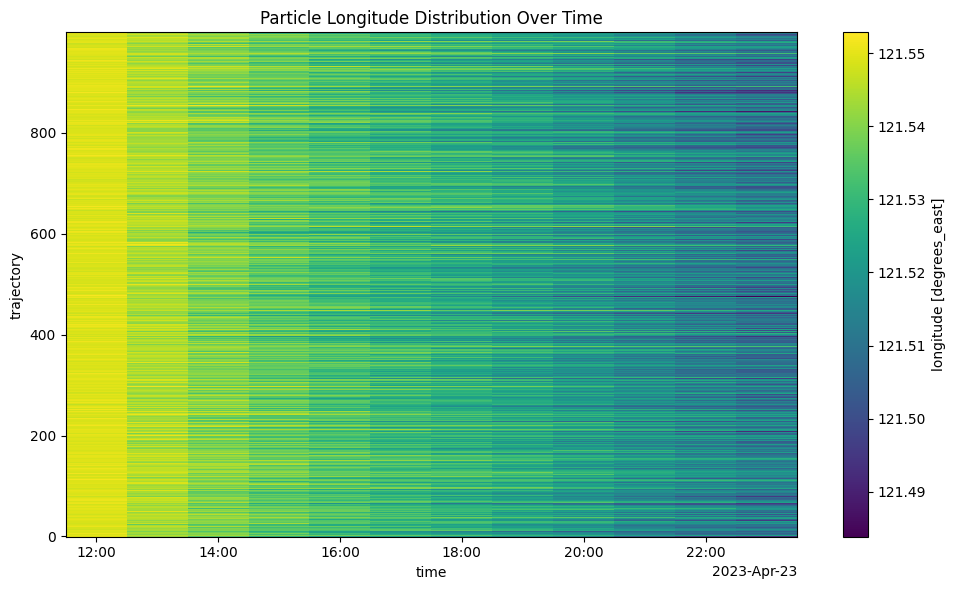

In [16]:
# Visualize the simulation data with xarray
import xarray as xr

if 'sim_path' in locals() and os.path.exists(sim_path):
    ds = xr.open_dataset(sim_path)
    print("Dataset structure:")
    print(ds)
    
    # Simple visualization
    try:
        # Plot longitude distribution
        ds['lon'].plot(figsize=(10, 6))
        plt.title('Particle Longitude Distribution Over Time')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Could not create visualization: {e}")
    
    ds.close()
else:
    print("Simulation file not found. Please run the simulation cell first.")


In [17]:
# Convert simulation results to DataFrame for analysis
import xarray as xr
import pandas as pd
import glob

# Find the most recent simulation file
sim_files = glob.glob(os.path.join(outputs_dir, 'simulation_*.nc'))
if not sim_files:
    print("No simulation files found. Please run the simulation first.")
else:
    sim_path = max(sim_files, key=os.path.getmtime)  # Get the most recent file
    print(f"Loading simulation from: {sim_path}")
    
    # Open with xarray and convert to DataFrame
    ds = xr.open_dataset(sim_path)
    
    # Convert to dataframe
    df = ds.to_dataframe().reset_index()
    
    # Display first few rows
    print("\nFirst 10 rows of simulation data:")
    print(df.head(10))
    
    print("\nAvailable columns:")
    print(df.columns.tolist())
    
    ds.close()


Loading simulation from: ..\outputs\simulation_20230423T1200Z_233110.nc

First 10 rows of simulation data:
   trajectory                time  status  age_seconds         lon        lat  \
0           0 2023-04-23 12:00:00     0.0          0.0  121.549759  13.301503   
1           0 2023-04-23 13:00:00     0.0       3600.0  121.541580  13.294641   
2           0 2023-04-23 14:00:00     0.0       7200.0  121.534294  13.290943   
3           0 2023-04-23 15:00:00     0.0      10800.0  121.528099  13.291119   
4           0 2023-04-23 16:00:00     0.0      14400.0  121.523888  13.290109   
5           0 2023-04-23 17:00:00     0.0      18000.0  121.524147  13.289822   
6           0 2023-04-23 18:00:00     0.0      21600.0  121.519943  13.285357   
7           0 2023-04-23 19:00:00     0.0      25200.0  121.516945  13.282269   
8           0 2023-04-23 20:00:00     0.0      28800.0  121.512695  13.279797   
9           0 2023-04-23 21:00:00     0.0      32400.0  121.504128  13.268537   

 

In [18]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
print(df.head(10))


   trajectory                time  status  age_seconds         lon        lat  mass_oil  viscosity     density  water_fraction
0           0 2023-04-23 12:00:00     0.0          0.0  121.549759  13.301503  0.877573   0.000045  877.572632        0.000000
1           0 2023-04-23 13:00:00     0.0       3600.0  121.541580  13.294641  0.731196   0.000165  877.848999        0.000000
2           0 2023-04-23 14:00:00     0.0       7200.0  121.534294  13.290943  0.690789   0.000364  877.848999        0.030382
3           0 2023-04-23 15:00:00     0.0      10800.0  121.528099  13.291119  0.678725   0.000528  884.655518        0.063345
4           0 2023-04-23 16:00:00     0.0      14400.0  121.523888  13.290109  0.674637   0.000615  888.601135        0.080021
5           0 2023-04-23 17:00:00     0.0      18000.0  121.524147  13.289822  0.672660   0.000655  890.380981        0.094411
6           0 2023-04-23 18:00:00     0.0      21600.0  121.519943  13.285357  0.671230   0.000706  893.386597 

In [19]:
# Save additional analysis results

def to_native(obj):
    try:
        import numpy as _np
        if isinstance(obj, _np.generic):
            return obj.item()
        if isinstance(obj, (list, tuple)):
            return [to_native(x) for x in obj]
        if isinstance(obj, dict):
            return {k: to_native(v) for k, v in obj.items()}
    except Exception:
        pass
    return obj

budget = to_native(o.get_oil_budget())

simulation_results = {
    'setup': {
        'date': date.strftime('%Y-%m-%d'),
        'release_time': release_time.strftime('%Y-%m-%dT%H:%MZ'),
        'release_location': {
            'latitude': float(release_lat),
            'longitude': float(release_lon)
        },
        'num_particles': num_particles,
        'duration_hours': duration_hours,
        'time_step_minutes': time_step_minutes
    },
    'results': {
        'final_active_elements': int(o.num_elements_active()),
        'deactivated_elements': int(o.num_elements_deactivated()),
        'oil_budget': budget,
        'outfile': outfile
    }
}

# Save results to JSON
results_file = os.path.join(outputs_dir, f'simulation_results_{release_time.strftime("%Y%m%dT%H%MZ")}.json')
with open(results_file, 'w') as f:
    json.dump(simulation_results, f, indent=2)

print(f"\nSimulation results saved to: {results_file}")

# Clean up
o.release_mem()

KeyError: "No variable named 'z'. Variables on the dataset include ['status', 'age_seconds', 'lon', 'lat', 'mass_oil', 'viscosity', 'density', 'water_fraction', 'trajectory', 'time']"

In [22]:
import xarray as xr
era5_ds = xr.open_dataset(era5_file)
print(era5_ds.data_vars)


Data variables:
    u10      (valid_time, latitude, longitude) float32 192B ...
    v10      (valid_time, latitude, longitude) float32 192B ...


In [23]:
# Verify data files exist and inspect them
import xarray as xr

print("Verifying downloaded data files...\n")

# Check ERA5 file
if os.path.exists(era5_file):
    print(f"✓ ERA5 file exists: {era5_file}")
    try:
        era5_ds = xr.open_dataset(era5_file)
        print(f"  Variables: {list(era5_ds.data_vars)}")
        print(f"  Dimensions: {dict(era5_ds.dims)}")
        era5_ds.close()
    except Exception as e:
        print(f"  Error reading file: {e}")
else:
    print(f"✗ ERA5 file not found: {era5_file}")

# Check CMEMS file
if os.path.exists(cmems_file):
    print(f"\n✓ CMEMS file exists: {cmems_file}")
    try:
        cmems_ds = xr.open_dataset(cmems_file)
        print(f"  Variables: {list(cmems_ds.data_vars)}")
        print(f"  Dimensions: {dict(cmems_ds.dims)}")
        cmems_ds.close()
    except Exception as e:
        print(f"  Error reading file: {e}")
else:
    print(f"\n✗ CMEMS file not found: {cmems_file}")

print("\nData verification complete.")


ERA5 file variables:
['u10', 'v10']
u10 attrs: {'GRIB_paramId': 165, 'GRIB_dataType': 'an', 'GRIB_numberOfPoints': 2, 'GRIB_typeOfLevel': 'surface', 'GRIB_stepUnits': 1, 'GRIB_stepType': 'instant', 'GRIB_gridType': 'regular_ll', 'GRIB_uvRelativeToGrid': 0, 'GRIB_NV': 0, 'GRIB_Nx': 2, 'GRIB_Ny': 1, 'GRIB_cfName': 'unknown', 'GRIB_cfVarName': 'u10', 'GRIB_gridDefinitionDescription': 'Latitude/Longitude Grid', 'GRIB_iDirectionIncrementInDegrees': 0.25, 'GRIB_iScansNegatively': 0, 'GRIB_jDirectionIncrementInDegrees': 0.25, 'GRIB_jPointsAreConsecutive': 0, 'GRIB_jScansPositively': 0, 'GRIB_latitudeOfFirstGridPointInDegrees': 13.246, 'GRIB_latitudeOfLastGridPointInDegrees': 13.245, 'GRIB_longitudeOfFirstGridPointInDegrees': 121.39, 'GRIB_longitudeOfLastGridPointInDegrees': 121.641, 'GRIB_missingValue': 3.4028234663852886e+38, 'GRIB_name': '10 metre U wind component', 'GRIB_shortName': '10u', 'GRIB_totalNumber': 0, 'GRIB_units': 'm s**-1', 'long_name': '10 metre U wind component', 'units': 'm

NameError: name 'era5_reader' is not defined

In [24]:
# Check reader time coverage
print("Reader time coverage:")
print(f"ERA5 coverage: {era5_reader.start_time} → {era5_reader.end_time}")
print(f"CMEMS coverage: {cmems_reader.start_time} → {cmems_reader.end_time}")
print(f"Release time: {release_time}")

# Verify release time is within coverage
if release_time >= era5_reader.start_time and release_time <= era5_reader.end_time:
    print("✓ Release time is within ERA5 coverage")
else:
    print("✗ Release time is OUTSIDE ERA5 coverage!")
    
if release_time >= cmems_reader.start_time and release_time <= cmems_reader.end_time:
    print("✓ Release time is within CMEMS coverage")
else:
    print("✗ Release time is OUTSIDE CMEMS coverage!")


NameError: name 'era5_reader' is not defined

In [25]:
# Check OpenOil model state
print("OpenOil model status:")
print(f"Number of elements active: {o.num_elements_active()}")
print(f"Number of elements deactivated: {o.num_elements_deactivated()}")
print(f"Model has results: {hasattr(o, 'result') and o.result is not None}")

if hasattr(o, 'result') and o.result is not None:
    print(f"Results time range: {o.result.time.values[0]} to {o.result.time.values[-1]}")


AttributeError: 'OpenOil' object has no attribute 'start_time'

In [26]:
print("ERA5 reader time coverage:")
print(f"  Start: {era5_reader.start_time}")
print(f"  End:   {era5_reader.end_time}")

print("CMEMS reader time coverage:")
print(f"  Start: {cmems_reader.start_time}")
print(f"  End:   {cmems_reader.end_time}")


ERA5 reader time coverage:


NameError: name 'era5_reader' is not defined

In [27]:
o.list_configspec()


environment:constant:x_sea_water_velocity [None] float min: -15, max: 15 [m/s] Component of ocean c...
environment:fallback:x_sea_water_velocity [None] float min: -15, max: 15 [m/s] Component of ocean c...
environment:constant:y_sea_water_velocity [None] float min: -15, max: 15 [m/s] Component of ocean c...
environment:fallback:y_sea_water_velocity [None] float min: -15, max: 15 [m/s] Component of ocean c...
environment:constant:x_wind         [None] float min: -50, max: 50 [m/s] Component of wind al...
environment:fallback:x_wind         [None] float min: -50, max: 50 [m/s] Component of wind al...
environment:constant:y_wind         [None] float min: -50, max: 50 [m/s] Component of wind al...
environment:fallback:y_wind         [None] float min: -50, max: 50 [m/s] Component of wind al...
environment:constant:sea_surface_height [None] float min: None, max: None [None] Use constant value f...
environment:fallback:sea_surface_height [0] float min: None, max: None [None] Fallback value fo